# Neural Networks Assignment, 2025 A2 <ignore>
## Overview
In this assessment, you will be asked to carry out three tasks. The first task involves building and training a simple CNN-based classifier for the Fashion MNIST dataset, and demonstrating the effectiveness of a technique to improve gradient flow. The second task involves building and training an unconditional GAN to generate images that look like those in the Fashion MNIST dataset, and using the discriminator to investigate the quality of the generated images. The third task involves augmenting the GAN to improve the generated images in some way.

## Instructions
### Code and Markdown cells
All of your report, including code and Markdown/text, ***must*** be written up in ***this*** notebook. Please make sure you change the title of this file so that XXXXXX is replaced by your candidate number. You can use code cells, where provided, to write code to implement, train, test, and analyse your NNs, as well as to generate figures to plot data and the results of your experiments. If you wish to add more code cells, you may do so immediately after the code cells that have been provided, but do not add any code cells anywhere else in this file. You must use the Markdown/text cells that are provided for writing the three report sections, one for each Task. These Markdown cells have "*Replace this text with your report for Task X*" in italics. Please replace that text with your own text. So that we can mark your reports with greater consistency, please ***do not***:

* add any of your own Markdown cells.
* rearrange the sequence of cells in this notebook.
* delete any cells, including the ones explaining what you need to do.

### Plotting figures
All plots of data ***must*** be produced as output from a code cell. Any plots that have been imported as images, rather than being the output of a plot function (such as that provided by matplotlib) will not receive marks. This is to ensure that you did the work to produce that plot. All figures should have an accompanying caption that states the Figure number and a detailed description of what the figure shows (see the guidenace in the file ```useful_code_for_figures_equations.ipynb```). 

### Writing code
Where relevant in your written report, e.g. when describing your methods, indicate where in your code the methods are implemented, including  the cell and line numbers (if you use VSCode, these are visible in the bottom right corner of the window). You might say, for example, "_layers 1-4 used 3x3 convolutional filters with a stride of 1 and padding of 1 (cell 5, line 30)_".  Please provide verbose comments throughout your code so that it is easy for us to interpret what you are attempting to achieve. Long comments are useful at the beginning of a block of code. Short comments, e.g. to explain the purpose of a new variable, or one of several steps in some analyses, are useful on every few lines of code, if not on every line. Please do not use the code cells for writing verbose responses to subtasks, which should instead be written in the provided Markdown cells.

# TASK 1 <ignore>

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# use GPU, if not availble use CPU, GPU makes simulation runs significantly faster
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# the Fashion MNIST classes
CLASSES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# convert images to tensors and normalise using Fashion MNIST's channel mean/std
# normalisation shifts pixel values to be zero-centred with std ~1

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.2860,), std=(0.3530,))
])

# download the dataset
full_train = torchvision.datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# split the 60k image training set 80/20 into 48k train and 12k validation
# seed=42 splits the data the same way for reproducbility
n_train = int(0.8 * len(full_train))
n_val   = len(full_train) - n_train
train_set, val_set = random_split(full_train, [n_train, n_val],
                                  generator=torch.Generator().manual_seed(42))

# batch size 64 
BATCH_SIZE = 64
training_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
value_loader   = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
testing_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_set)}  |  Val: {len(val_set)}  |  Test: {len(test_set)}")


Using device: cpu
Train: 48000  |  Val: 12000  |  Test: 10000


In [4]:
# 5-layer CNN classifier for Fashion MNIST

class CNN(nn.Module):
    def __init__(self, use_bn=True):
        super().__init__()
        self.use_bn = use_bn

        # Layer 1
        self.conv1 = nn.Conv2d(1,   32,  kernel_size=3, padding=1)
        self.bn1   = nn.BatchNorm2d(32)

        # Layer 2
        self.conv2 = nn.Conv2d(32,  64,  kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm2d(64)

        # Layer 3
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm2d(128)

        # Layer 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm2d(256)

        # Layer 5
        self.conv5 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn5   = nn.BatchNorm2d(512)

        self.pool = nn.MaxPool2d(2, 2)
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(512, 10)

    def forward(self, x):
        # Layer 1 edges and gradients
        x = self.conv1(x)
        if self.use_bn: x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 2 coreners and textures
        x = self.conv2(x)
        if self.use_bn: x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 3 simple shapes and patterns
        x = self.conv3(x)
        if self.use_bn: x = self.bn3(x)
        x = F.relu(x)

        # Layer 4 parts and shapes
        x = self.conv4(x)
        if self.use_bn: x = self.bn4(x)
        x = F.relu(x)
        x = self.pool(x)

        # Layer 5 object-level features
        x = self.conv5(x)
        if self.use_bn: x = self.bn5(x)
        x = F.relu(x)

        # Global Average Pooling
        x = self.gap(x)
        x = x.view(x.size(0), -1)

        x = self.drop(x)
        x = self.fc(x)
        return x


In [5]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        # move batch to the same device as the model
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            # move batch to the same device as the model
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return total_loss / total, correct / total



LR = 0.0001
  epoch 1/5  val acc: 88.4%
  epoch 2/5  val acc: 90.1%
  epoch 3/5  val acc: 90.5%
  epoch 4/5  val acc: 90.1%
  epoch 5/5  val acc: 90.9%

LR = 0.0005
  epoch 1/5  val acc: 89.8%
  epoch 2/5  val acc: 90.2%
  epoch 3/5  val acc: 90.9%
  epoch 4/5  val acc: 91.8%
  epoch 5/5  val acc: 91.6%

LR = 0.001
  epoch 1/5  val acc: 88.8%
  epoch 2/5  val acc: 88.1%
  epoch 3/5  val acc: 92.2%
  epoch 4/5  val acc: 91.9%
  epoch 5/5  val acc: 91.2%

LR = 0.005
  epoch 1/5  val acc: 88.7%
  epoch 2/5  val acc: 90.5%
  epoch 3/5  val acc: 89.7%
  epoch 4/5  val acc: 91.6%
  epoch 5/5  val acc: 92.1%

LR = 0.01
  epoch 1/5  val acc: 89.0%
  epoch 2/5  val acc: 88.6%
  epoch 3/5  val acc: 90.9%
  epoch 4/5  val acc: 91.4%
  epoch 5/5  val acc: 91.5%

Best LR: 0.005  (val acc = 92.1% at epoch 5)


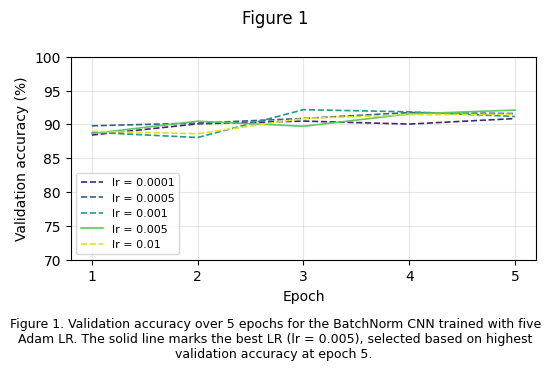

In [6]:
# Learning rate search Figure 1

LEARNING_RATES = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
LR_EPOCHS = 5

lr_value_accuracy_histories = {}
criterion = nn.CrossEntropyLoss()

for lr in LEARNING_RATES:
    model_lr = CNN(use_bn=True).to(device)
    
    opt_lr   = optim.Adam(model_lr.parameters(), lr=lr)
    value_accuracy = []

    print(f"\nLR = {lr}")
    for epoch in range(1, LR_EPOCHS + 1):
        train_one_epoch(model_lr, training_loader, criterion, opt_lr)
        _, v_acc = evaluate(model_lr, value_loader, criterion)
        value_accuracy.append(v_acc * 100)
        print(f"  epoch {epoch}/{LR_EPOCHS}  val acc: {v_acc*100:.1f}%")

    lr_value_accuracy_histories[lr] = value_accuracy

# select the best LR based on final epoch val accuracy
BEST_LR = max(LEARNING_RATES, key=lambda r: lr_value_accuracy_histories[r][-1])
print(f"\nBest LR: {BEST_LR}  (val acc = {lr_value_accuracy_histories[BEST_LR][-1]:.1f}% at epoch {LR_EPOCHS})")

# Figure 1: LR search value accuracy curves for 5 LR
figWidth  = 14.
figHeight = 8.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 1')

colors = plt.cm.viridis([0.1, 0.3, 0.55, 0.75, 0.95])
for (lr, accs), col in zip(lr_value_accuracy_histories.items(), colors):
    ax.plot(range(1, LR_EPOCHS + 1), accs, linewidth=1.2, color=col,
            label=f'lr = {lr}',
            linestyle='-' if lr == BEST_LR else '--')

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation accuracy (%)')
ax.set_ylim([70, 100])
ax.xaxis.set_ticks(range(1, LR_EPOCHS + 1))
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

txt = (f"Figure 1. Validation accuracy over {LR_EPOCHS} epochs for the BatchNorm CNN "
       f"trained with five Adam LR. The solid line marks the best LR "
       f"(lr = {BEST_LR}), selected based on highest validation accuracy at epoch {LR_EPOCHS}. ")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()


In [7]:
# train_model wraps train_one_epoch and evaluate to run a complete training run
# recording loss and accuracy each epoch so we can plot learning curves afterwards.

def train_model(use_bn, n_epochs=15, lr=1e-3):
    # move model to GPU
    model     = CNN(use_bn=use_bn).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'training_loss': [], 'value_loss': [], 'training_accuracy': [], 'value_accuracy': []}

    name = "BatchNorm" if use_bn else "Baseline (no BN)"
    print(f"\nTraining: {name}  lr={lr}")

    for epoch in range(1, n_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, training_loader, criterion, optimizer)
        v_loss, v_acc = evaluate(model, value_loader, criterion)

        history['training_loss'].append(t_loss)
        history['value_loss'].append(v_loss)
        history['training_accuracy'].append(t_acc)
        history['value_accuracy'].append(v_acc)

        print(f"epoch {epoch:2d}/{n_epochs}"
              f"train {t_loss:.4f} / {t_acc*100:.1f}%  |  "
              f"val {v_loss:.4f} / {v_acc*100:.1f}%")

    return model, history


# train both variants for 15 epochs
N_EPOCHS = 15
model_baseline, hist_baseline = train_model(use_bn=False, n_epochs=N_EPOCHS, lr=BEST_LR)
model_bn, hist_bn = train_model(use_bn=True,  n_epochs=N_EPOCHS, lr=BEST_LR)



Training: Baseline (no BN)  lr=0.005
  epoch  1/15  train 0.6133 / 77.5%  |  val 0.3945 / 85.8%
  epoch  2/15  train 0.3583 / 86.9%  |  val 0.3160 / 88.4%
  epoch  3/15  train 0.3166 / 88.4%  |  val 0.3277 / 87.9%
  epoch  4/15  train 0.2938 / 89.1%  |  val 0.3069 / 89.0%
  epoch  5/15  train 0.2794 / 89.7%  |  val 0.3160 / 88.7%
  epoch  6/15  train 0.2649 / 90.2%  |  val 0.2832 / 89.8%
  epoch  7/15  train 0.2568 / 90.5%  |  val 0.2925 / 89.8%
  epoch  8/15  train 0.2517 / 90.7%  |  val 0.3191 / 88.9%
  epoch  9/15  train 0.2454 / 90.9%  |  val 0.3139 / 89.2%
  epoch 10/15  train 0.2387 / 91.1%  |  val 0.2967 / 89.5%
  epoch 11/15  train 0.2301 / 91.5%  |  val 0.3199 / 88.9%
  epoch 12/15  train 0.2290 / 91.5%  |  val 0.3165 / 89.0%
  epoch 13/15  train 0.2222 / 91.7%  |  val 0.2975 / 89.7%
  epoch 14/15  train 0.2223 / 91.8%  |  val 0.3211 / 89.4%
  epoch 15/15  train 0.2201 / 92.0%  |  val 0.3016 / 89.8%

Training: BatchNorm  lr=0.005
  epoch  1/15  train 0.4338 / 84.0%  |  val 0.

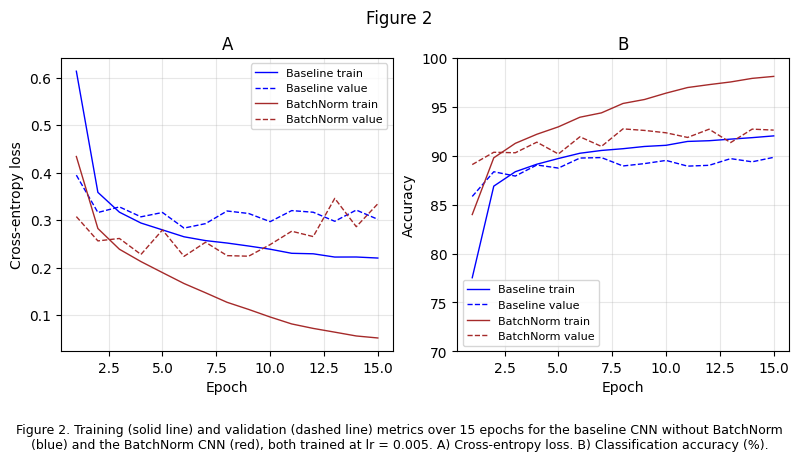

In [10]:
# Figure 2 BatchNorm ablation LR
# convergence speed and final accuracy

epochs = range(1, N_EPOCHS + 1)

figWidth  = 20.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 2')

# panel A: cross entropy loss
axs[0].set_title('A')
axs[0].plot(epochs, hist_baseline['training_loss'], color='blue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[0].plot(epochs, hist_baseline['value_loss'],   color='blue', linestyle='--', linewidth=1.0, label='Baseline value')
axs[0].plot(epochs, hist_bn['training_loss'],       color='brown', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[0].plot(epochs, hist_bn['value_loss'],         color='brown', linestyle='--', linewidth=1.0, label='BatchNorm value')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Cross-entropy loss')
axs[0].legend(fontsize=8)
axs[0].grid(True, alpha=0.3)

# panel B: classification accuracy
axs[1].set_title('B')
axs[1].plot(epochs, [v*100 for v in hist_baseline['training_accuracy']], color='blue', linestyle='-',  linewidth=1.0, label='Baseline train')
axs[1].plot(epochs, [v*100 for v in hist_baseline['value_accuracy']],   color='blue', linestyle='--', linewidth=1.0, label='Baseline value')
axs[1].plot(epochs, [v*100 for v in hist_bn['training_accuracy']],       color='brown', linestyle='-',  linewidth=1.0, label='BatchNorm train')
axs[1].plot(epochs, [v*100 for v in hist_bn['value_accuracy']],         color='brown', linestyle='--', linewidth=1.0, label='BatchNorm value')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([70, 100])
axs[1].legend(fontsize=8)
axs[1].grid(True, alpha=0.3)

txt = (f"Figure 2. Training (solid line) and validation (dashed line) metrics over {N_EPOCHS} epochs "
       f"for the baseline CNN without BatchNorm (blue) and the BatchNorm CNN (red), "
       f"both trained at lr = {BEST_LR}. "
       f"A) Cross-entropy loss. B) Classification accuracy (%).")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()


Test-set results:
  Baseline CNN  — loss: 0.3197   accuracy: 89.13%
  BatchNorm CNN — loss: 0.3787   accuracy: 91.99%

Per-class test accuracy (BatchNorm CNN):
  T-shirt/top    : 91.2%
  Trouser        : 98.3%
  Pullover       : 90.8%
  Dress          : 91.9%
  Coat           : 89.9%
  Sandal         : 94.4%
  Shirt          : 70.8%
  Sneaker        : 97.2%
  Bag            : 97.9%
  Ankle boot     : 97.5%


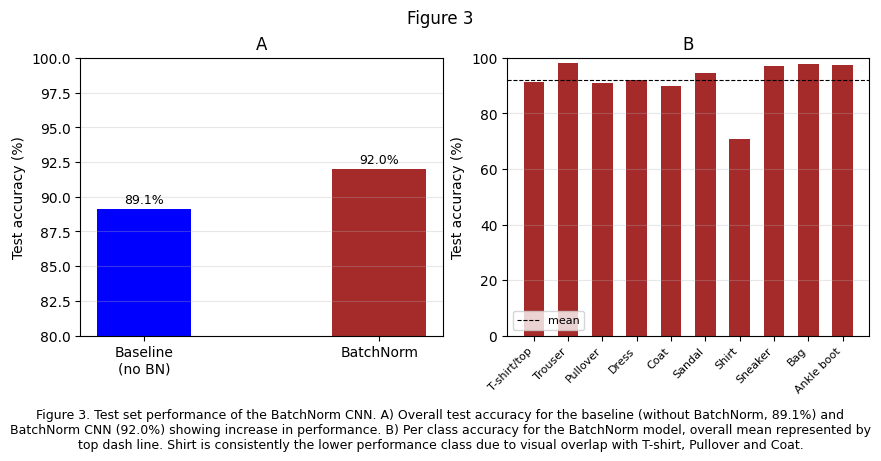

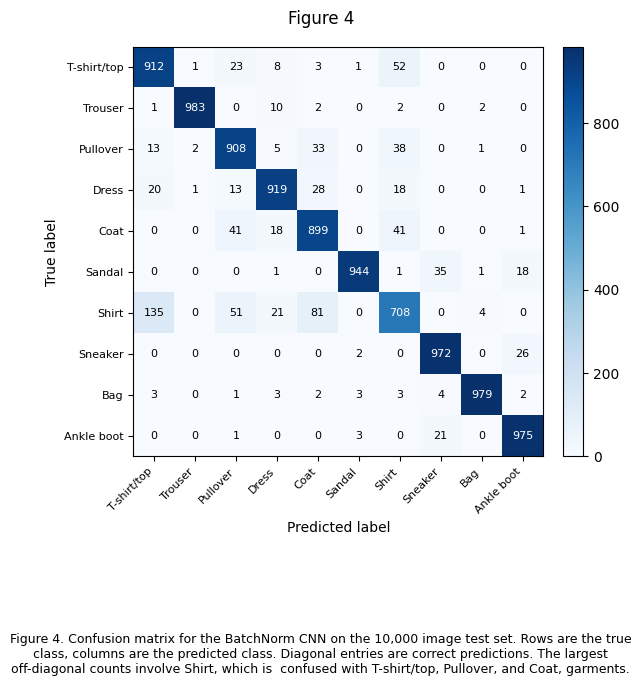

In [11]:
# Evaluate both models on the held-out test set.

criterion = nn.CrossEntropyLoss()

test_loss_bl, test_acc_bl = evaluate(model_baseline, testing_loader, criterion)
test_loss_bn, test_acc_bn = evaluate(model_bn,       testing_loader, criterion)

print("Test-set results:")
print(f"  Baseline CNN  — loss: {test_loss_bl:.4f}   accuracy: {test_acc_bl*100:.2f}%")
print(f"  BatchNorm CNN — loss: {test_loss_bn:.4f}   accuracy: {test_acc_bn*100:.2f}%")

# per class accuracy for the BatchNorm model
# collect confusion matrix predictions

correct_per_class = {c: 0 for c in CLASSES}
total_per_class   = {c: 0 for c in CLASSES}
all_preds, all_labels_list = [], []

model_bn.eval()
with torch.no_grad():
    for images, labels in testing_loader:
        # move batch to GPU
        images, labels = images.to(device), labels.to(device)
        outputs = model_bn(images)
        _, predicted = torch.max(outputs, 1)

        # move back to CPU for numpy conversion
        all_preds.extend(predicted.cpu().numpy())
        all_labels_list.extend(labels.cpu().numpy())

        for lbl, pred in zip(labels, predicted):
            cls = CLASSES[lbl.item()]
            total_per_class[cls] += 1
            if lbl == pred:
                correct_per_class[cls] += 1

per_class_acc = [100 * correct_per_class[c] / total_per_class[c] for c in CLASSES]

print("\nPer-class test accuracy (BatchNorm CNN):")
for cls, acc in zip(CLASSES, per_class_acc):
    print(f"  {cls:15s}: {acc:.1f}%")

# Figure 3: Panel A: overall BatchNorm ablation + Panel B: per class test accuracy

figWidth  = 22.
figHeight = 10.
fig, axs = plt.subplots(1, 2, constrained_layout=True,
                         figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 3')

axs[0].set_title('A')
bars = axs[0].bar(['Baseline\n(no BN)', 'BatchNorm'],
                   [test_acc_bl * 100, test_acc_bn * 100],
                   color=['blue', 'brown'], width=0.4)
axs[0].set_ylabel('Test accuracy (%)')
axs[0].set_ylim([80, 100])
for bar, val in zip(bars, [test_acc_bl * 100, test_acc_bn * 100]):
    axs[0].text(bar.get_x() + bar.get_width() / 2, val + 0.2,
                f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
axs[0].grid(True, axis='y', alpha=0.3)

axs[1].set_title('B')
x = np.arange(len(CLASSES))
axs[1].bar(x, per_class_acc, color='brown', width=0.6)
axs[1].set_xticks(x)
axs[1].set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
axs[1].set_ylabel('Test accuracy (%)')
axs[1].set_ylim([0, 100])
axs[1].axhline(test_acc_bn * 100, color='black', linestyle='--', linewidth=0.8, label='mean')
axs[1].legend(fontsize=8)
axs[1].grid(True, axis='y', alpha=0.3)

txt = (f"Figure 3. Test set performance of the BatchNorm CNN. "
       f"A) Overall test accuracy for the baseline (without BatchNorm, {test_acc_bl*100:.1f}%) "
       f"and BatchNorm CNN ({test_acc_bn*100:.1f}%) showing increase in performance. "
       f"B) Per class accuracy for the BatchNorm model, overall mean represented by top dash line. "
       f"Shirt is consistently the lower performance class due to visual overlap with T-shirt, Pullover and Coat.")
plt.figtext(0.5, -0.12, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.show()

# Figure 4: Confusion matrix

cm = confusion_matrix(all_labels_list, all_preds)

figWidth  = 16.
figHeight = 14.
fig, ax = plt.subplots(figsize=tuple(np.array((figWidth, figHeight)) / 2.54))
fig.suptitle('Figure 4')

im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > thresh else 'black')

tick_marks = np.arange(len(CLASSES))
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(CLASSES, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(CLASSES, fontsize=8)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')

txt = ("Figure 4. Confusion matrix for the BatchNorm CNN on the 10,000 image test set. "
       "Rows are the true class, columns are the predicted class. "
       "Diagonal entries are correct predictions. "
       "The largest off-diagonal counts involve Shirt, which is  confused with "
       "T-shirt/top, Pullover, and Coat, garments.")
plt.figtext(0.5, -0.22, txt, wrap=True, horizontalalignment='center', fontsize=9)

plt.tight_layout()
plt.show()


# TASK 2 <ignore>

*Replace this text with your report for Task 2*

In [ ]:
###
### Use this code cell for Task 2. You may create code cells immediately 
### after this one if you need to.
###

# TASK 3 <ignore>

*Replace this text with your report for Task 3*

In [ ]:
###
### Use this code cell for Task 3. You may create code cells immediately 
### after this one if you need to.
###

## References <ignore>

*Replace this text with full references for any published articles that you cite in the report*